# Utility indifference pricing with an unhedgeable stochastic factor (payoff on the factor)

This notebook corrects the **payoff** in the Monte Carlo part to be **on the stochastic factor** (the variance/volatility factor), i.e.

$$G = g(Y_T)\quad\text{(here }Y_t=v_t\text{ is the stochastic variance factor).}$$

You hedge the claim **using the traded stock** $S$, because the factor and the stock share correlated Brownian shocks.

We implement the reduced-form representation used in the (Touzi-style) exam problem:
- Exponential utility $U(x)=-e^{-a x}$
- One traded asset $S$, one nontraded factor $Y$
- Indifference price $p_0(t,y)$ computed from a weighted expectation under the **distorted factor dynamics** (the "tilde" factor).

The notebook is self-contained and focuses on:
1. A correct pricing estimator for **factor payoff** $g(v_T)$
2. A more stable hedge-sensitivity estimator using **common random numbers** + **central differences**
3. Parameter sweeps (risk aversion, correlation, maturity, strike, vol-of-vol, mean reversion)

---

## Model (Heston-style with one traded asset + one factor)

We use (physical measure) dynamics with stochastic variance $v_t\ge 0$:

$$\frac{dS_t}{S_t}=\mu\,dt+\sqrt{v_t}\,dW_t^{(1)},
\qquad
dv_t=\kappa(\bar v-v_t)\,dt+\xi\sqrt{v_t}\,dB_t,$$
where
$$dB_t = \rho\,dW_t^{(1)}+\sqrt{1-\rho^2}\,dW_t^{(2)}.$$

The "market price of risk" function is
$$\lambda(y) = \frac{\mu(y)}{\sigma(y)}.$$
Here $\sigma(y)=\sqrt{y}$. If you take $\mu(y)\equiv \mu$ constant, then $\lambda(y)=\mu/\sqrt{y}$, which makes the weighting term involve $\int \lambda^2 dt = \int \mu^2/v_t \,dt$. Numerically we will **floor** $v_t$ to avoid division-by-zero.

---

## Payoff (corrected)
We now take the claim to be on the factor:
- default: **variance call** $g(v_T)=\max(v_T-K,0)$

You can easily swap in other $g(\cdot)$.


In [61]:

import numpy as np
import pandas as pd
import math
from dataclasses import dataclass
from typing import Callable, Optional, Dict, Tuple

import matplotlib.pyplot as plt

np.random.seed(0)


In [62]:

@dataclass
class HestonFactorParams:
    # factor dynamics (variance)
    kappa: float = 3.0        # mean reversion speed
    vbar: float = 0.04        # long-run variance
    xi: float = 0.5           # vol-of-vol
    rho: float = -0.7         # correlation between stock BM and factor BM

    # stock drift used inside lambda(y)=mu(y)/sigma(y)
    mu: float = 0.08          # annual drift (physical measure)

    # time discretization
    T: float = 1.0            # years
    n_steps: int = 252        # time steps

    # numerical safety
    v_floor: float = 1e-10    # to avoid division by 0 in lambda^2 integral

    @property
    def dt(self) -> float:
        return self.T / self.n_steps


In [63]:

def payoff_variance_call(vT: np.ndarray, K: float) -> np.ndarray:
    # Variance call payoff g(v_T) = (v_T - K)^+
    return np.maximum(vT - K, 0.0)

def payoff_variance_put(vT: np.ndarray, K: float) -> np.ndarray:
    return np.maximum(K - vT, 0.0)

def payoff_linear(vT: np.ndarray) -> np.ndarray:
    # Variance swap style payoff g(v_T)=v_T
    return vT

def payoff_capped_linear(vT: np.ndarray, cap: float) -> np.ndarray:
    # g(v_T) = min(v_T, cap)
    return np.minimum(vT, cap)


## Simulating the **tilde** factor $\tilde v$

From the reduced-form representation, we simulate a *distorted* factor process $\tilde v$ with drift shift
$$\eta(y)\ \mapsto\ \eta(y)-\rho\,\gamma(y)\,\lambda(y),$$
where here
- $\eta(y)=\kappa(\bar v - y)$
- $\gamma(y)=\xi\sqrt{y}$
- $\lambda(y)=\mu/\sqrt{y}$ (if $\mu$ constant and $\sigma(y)=\sqrt{y}$)

So:
$$d\tilde v_t = \Big(\kappa(\bar v-\tilde v_t) - \rho\,\xi\sqrt{\tilde v_t}\,\lambda(\tilde v_t)\Big)\,dt + \xi\sqrt{\tilde v_t}\,dB_t.$$

We simulate $dB_t$ as a single Brownian increment.
(You do **not** need to simulate the stock $S$ for factor-payoff pricing.)


In [64]:
def lambda_of_v(v: np.ndarray, params: HestonFactorParams) -> np.ndarray:
    """
    Market price of factor risk: lambda(v) = mu(v)/sigma(v).

    In this project we use the **canonical Heston-style choice**
        sigma(v) = sqrt(v),   mu(v) = mu (constant)
    so
        lambda(v) = mu / sqrt(v).

    We always apply a small floor to avoid division by ~0 when v is very small.
    """
    v_safe = np.maximum(v, params.v_floor)
    return params.mu / np.sqrt(v_safe)


def _cir_exact_step(v: np.ndarray, kappa: float, theta: float, xi: float, dt: float) -> np.ndarray:
    """
    One exact step of the CIR process:
        dv_t = kappa (theta - v_t) dt + xi sqrt(v_t) dW_t.

    Transition law: v_{t+dt} = c * ChiSq(df=d, nonc=lambda),
    where ChiSq is noncentral chi-square.
    """
    v = np.maximum(v, 0.0)

    # Handle degenerate cases defensively.
    if kappa <= 0 or xi <= 0 or dt <= 0:
        raise ValueError("Require kappa>0, xi>0, dt>0 for CIR exact scheme.")

    exp_kdt = math.exp(-kappa * dt)
    c = (xi * xi) * (1.0 - exp_kdt) / (4.0 * kappa)
    d = 4.0 * kappa * theta / (xi * xi)
    lam = 4.0 * kappa * exp_kdt * v / ((xi * xi) * (1.0 - exp_kdt))

    # numpy draws elementwise for arrays
    return c * np.random.noncentral_chisquare(df=d, nonc=lam, size=v.shape)


def simulate_tilde_variance_paths(
    v0: float,
    params: HestonFactorParams,
    Z: Optional[np.ndarray] = None,
    n_paths: int = 20000,
    scheme: str = "exact",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simulate the *tilde* variance process used in the reduced-form representation.

    Under the measure-change in the paper, the factor becomes:
        d\tilde v_t = [kappa (vbar - \tilde v_t) - rho * gamma(\tilde v_t) * lambda(\tilde v_t)] dt
                      + gamma(\tilde v_t) dW_t,
    where gamma(v)=xi*sqrt(v) and lambda(v)=mu/sqrt(v).

    **Key simplification** (important!):
        gamma(v)*lambda(v) = xi*sqrt(v) * mu/sqrt(v) = xi*mu  (constant)
    so the drift is still affine:
        d\tilde v_t = kappa(\tilde vbar - \tilde v_t) dt + xi sqrt(\tilde v_t) dW_t
    with shifted mean level
        \tilde vbar = vbar - rho * xi * mu / kappa.

    Therefore we can (and should) use the **exact CIR transition** by default.

    Returns:
      v_paths: (n_paths, n_steps+1)
      lambda_sq_int: (n_paths,)  approximation of \int_0^T lambda(\tilde v_t)^2 dt
    """
    dt = params.dt
    n_steps = params.n_steps

    if scheme not in {"exact", "euler_full_trunc"}:
        raise ValueError("scheme must be 'exact' or 'euler_full_trunc'")

    # shifted mean-reversion level under the tilde measure
    vbar_tilde = params.vbar - (params.rho * params.xi * params.mu) / params.kappa

    v = np.empty((n_paths, n_steps + 1), dtype=float)
    v[:, 0] = v0
    lam_sq_int = np.zeros(n_paths, dtype=float)

    if scheme == "exact":
        for t in range(n_steps):
            vt = v[:, t]
            # exact CIR step with theta = vbar_tilde
            v_next = _cir_exact_step(vt, params.kappa, vbar_tilde, params.xi, dt)
            v[:, t + 1] = np.maximum(v_next, 0.0)

            lam = lambda_of_v(vt, params)
            lam_sq_int += (lam ** 2) * dt

    else:
        # full truncation Euler (kept for comparison / debugging)
        if Z is None:
            Z = np.random.normal(size=(n_paths, n_steps))
        else:
            assert Z.shape == (n_paths, n_steps)

        for t in range(n_steps):
            vt = np.maximum(v[:, t], 0.0)
            sqrt_v = np.sqrt(vt)

            lam = lambda_of_v(vt, params)

            drift = params.kappa * (vbar_tilde - vt)
            dv = drift * dt + params.xi * sqrt_v * math.sqrt(dt) * Z[:, t]
            v_next = vt + dv

            v[:, t + 1] = np.maximum(v_next, 0.0)
            lam_sq_int += (lam ** 2) * dt

    return v, lam_sq_int


## Utility indifference price for **factor** payoff

Let $\delta = 1-\rho^2$. The (time-0) indifference price can be written as

$$p_0(0,v_0)=\frac{1}{a\,\delta}\log\left(\frac{\mathbb E[\exp(\delta(a g(\tilde v_T) - \frac12\int_0^T \lambda(\tilde v_t)^2 dt))]}{\mathbb E[\exp(-\delta\frac12\int_0^T \lambda(\tilde v_t)^2 dt)]}\right).$$

Numerically:
- simulate $\tilde v$
- compute
  - $A_i = \exp(-\delta \tfrac12 I_i)\exp(\delta a g_i)$
  - $B_i = \exp(-\delta \tfrac12 I_i)$
- ratio $R = \bar A / \bar B$
- price $p_0 = \frac{1}{a\delta}\log R$

We also compute an approximate **standard error** for $p_0$ using a delta-method for $\log(\bar A)-\log(\bar B)$.


In [65]:

def indifference_price_factor(
    v0: float,
    payoff_fn: Callable[[np.ndarray], np.ndarray],
    a: float,
    params: HestonFactorParams,
    n_paths: int = 20000,
    Z: Optional[np.ndarray] = None
) -> Dict[str, float]:
    """
    Compute time-0 indifference price p0(0,v0) for a claim g(tilde_v_T).

    Returns dict with price, stderr, and diagnostics.
    """
    rho = params.rho
    delta = 1.0 - rho**2
    if delta <= 0:
        raise ValueError("Need |rho|<1 so delta=1-rho^2>0 for this transform.")

    v_paths, lam_sq_int = simulate_tilde_variance_paths(v0=v0, params=params, Z=Z, n_paths=n_paths)
    vT = v_paths[:, -1]
    g = payoff_fn(vT)

    B = np.exp(-0.5 * delta * lam_sq_int)
    A = B * np.exp(delta * a * g)

    meanA = A.mean()
    meanB = B.mean()
    ratio = meanA / meanB
    price = (1.0 / (a * delta)) * np.log(ratio)

    # delta-method stderr for price:
    h = (A / meanA) - (B / meanB)
    var_log_ratio = h.var(ddof=1) / n_paths
    stderr_price = (1.0 / (a * delta)) * math.sqrt(max(var_log_ratio, 0.0))

    return {
        "price": float(price),
        "stderr": float(stderr_price),
        "ratio": float(ratio),
        "meanA": float(meanA),
        "meanB": float(meanB),
        "vT_mean": float(vT.mean()),
        "vT_std": float(vT.std(ddof=1)),
    }


## Hedge-sensitivity (incremental stock demand induced by the factor claim)

From the problem-set identity (for this class of models),
$$\hat\theta_g(t,y)-\hat\theta_0(t,y)=\frac{\rho\,\gamma(y)}{\sigma(y)}\,\partial_y p_0(t,y).$$

In our Heston-style parametrization:
- $\sigma(y)=\sqrt{y}$
- $\gamma(y)=\xi\sqrt{y}$

So $\gamma/\sigma = \xi$ and at time 0,
$$\Delta\theta_0 := \hat\theta_g(0,v_0)-\hat\theta_0(0,v_0)\approx \rho\,\xi\,\partial_{v_0} p_0(0,v_0).$$

We estimate $\partial_{v_0} p_0$ by a **central difference** using the same random numbers (**common random numbers**) to reduce Monte Carlo noise.


In [66]:

def hedge_increment_at_t0(
    v0: float,
    payoff_fn: Callable[[np.ndarray], np.ndarray],
    a: float,
    params: HestonFactorParams,
    n_paths: int = 40000,
    bump: float = 1e-4,
    seed: int = 123
) -> Dict[str, float]:
    """
    Estimate d/dv0 p0(0,v0) via central difference with common random numbers,
    and return DeltaTheta0 = rho*xi*dpdv0.
    """
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(size=(n_paths, params.n_steps))

    res0 = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=a, params=params, n_paths=n_paths, Z=Z)
    res_plus = indifference_price_factor(v0=v0 + bump, payoff_fn=payoff_fn, a=a, params=params, n_paths=n_paths, Z=Z)
    res_minus = indifference_price_factor(v0=max(v0 - bump, 1e-12), payoff_fn=payoff_fn, a=a, params=params, n_paths=n_paths, Z=Z)

    dpdv0 = (res_plus["price"] - res_minus["price"]) / (2.0 * bump)
    delta_theta0 = params.rho * params.xi * dpdv0

    return {
        "price": res0["price"],
        "price_stderr": res0["stderr"],
        "dpdv0": float(dpdv0),
        "delta_theta0": float(delta_theta0),
        "bump": float(bump),
        "n_paths": int(n_paths),
    }



## Baseline run (factor payoff)

We'll price a **variance call** payoff \(g(v_T)=(v_T-K)^+\) and compute the hedge increment \(\Delta\theta_0\).


In [67]:

# Baseline parameters (annualized units)
params = HestonFactorParams(
    kappa=3.0,
    vbar=0.04,       # long run variance (20% vol)^2
    xi=0.6,          # vol-of-vol
    rho=-0.7,
    mu=0.08,         # stock drift (physical)
    T=1.0,
    n_steps=252,
    v_floor=1e-10
)

v0 = 0.04           # initial variance
a = 3.0             # risk aversion for exponential utility (bigger => more risk-averse)
K_var = 0.05        # strike on variance

payoff_fn = lambda vT: payoff_variance_call(vT, K=K_var)

res = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=a, params=params, n_paths=30000)
res


{'price': 0.025700351464360675,
 'stderr': 0.00034840222578730323,
 'ratio': 1.0401048628569665,
 'meanA': 0.7343216489971528,
 'meanB': 0.7060073221656838,
 'vT_mean': 0.05087874855528833,
 'vT_std': 0.05480560209809336}

In [68]:

hedge_res = hedge_increment_at_t0(v0=v0, payoff_fn=payoff_fn, a=a, params=params, n_paths=40000, bump=1e-4, seed=7)
hedge_res


{'price': 0.02537871189776149,
 'price_stderr': 0.00030081196792183345,
 'dpdv0': 1.2867857660542152,
 'delta_theta0': -0.5404500217427703,
 'bump': 0.0001,
 'n_paths': 40000}


## Parameter sweeps

We re-run the key comparative statics for **factor payoff**:

- Correlation \(\rho\)
- Risk aversion \(a\)
- Maturity \(T\)
- Variance strike \(K\)
- Vol-of-vol \(\xi\)

We report:
- Indifference price \(p_0\)
- Hedge increment \(\Delta\theta_0 \approx \rho\xi \partial_{v_0} p_0\)

**Tip:** start with smaller `n_paths` to explore, then increase for high-quality figures.


In [69]:

def sweep_parameter(
    name: str,
    values: np.ndarray,
    base_params: HestonFactorParams,
    v0: float,
    a: float,
    payoff_fn: Callable[[np.ndarray], np.ndarray],
    n_paths_price: int = 20000,
    n_paths_hedge: int = 25000,
    bump: float = 1e-4,
    seed: int = 123
) -> pd.DataFrame:
    rows = []
    for val in values:
        p_dict = base_params.__dict__.copy()
        p_dict[name] = float(val)
        p_new = HestonFactorParams(**p_dict)

        pr = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=a, params=p_new, n_paths=n_paths_price)
        hr = hedge_increment_at_t0(v0=v0, payoff_fn=payoff_fn, a=a, params=p_new, n_paths=n_paths_hedge, bump=bump, seed=seed)

        rows.append({
            name: float(val),
            "price": pr["price"],
            "price_stderr": pr["stderr"],
            "delta_theta0": hr["delta_theta0"],
            "dpdv0": hr["dpdv0"],
        })
    return pd.DataFrame(rows)


In [70]:
# 1) Sweep rho (correlation between stock returns and factor shocks)
# More granular grid to capture nonlinearities around rho=0 (spanning collapse)
rho_grid = np.linspace(-0.95, 0.95, 39)
df_rho = sweep_parameter(
    name="rho",
    values=rho_grid,
    base_params=params,
    v0=v0,
    a=a,
    payoff_fn=payoff_fn,
    n_paths_price=20000,
    n_paths_hedge=25000,
    bump=1e-4,
    seed=11
)
df_rho


,rho,price,price_stderr,delta_theta0,dpdv0
0,-0.95,0.023747,0.000345,1.433553,-2.515005
1,-0.90,0.024555,0.000363,-0.144272,0.267170
2,-0.85,0.024602,0.000369,-0.535764,1.050518
3,-0.80,0.025001,0.000388,-1.484444,3.092593
4,-0.75,0.025519,0.000415,1.122912,-2.495359
5,-0.70,0.025631,0.000429,0.481617,-1.146708
6,-0.65,0.025750,0.000436,1.090678,-2.796611
7,-0.60,0.026873,0.000479,-0.997019,2.769497
8,-0.55,0.025575,0.000445,1.113006,-3.372747
9,-0.50,0.026934,0.000515,-0.332904,1.109680


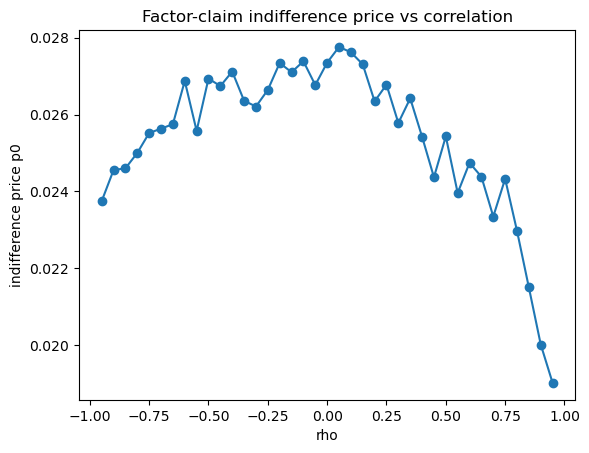

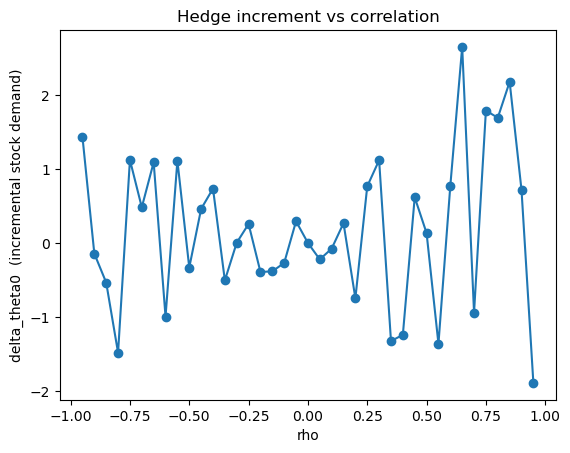

In [71]:

plt.figure()
plt.plot(df_rho["rho"], df_rho["price"], marker="o")
plt.xlabel("rho")
plt.ylabel("indifference price p0")
plt.title("Factor-claim indifference price vs correlation")
plt.show()

plt.figure()
plt.plot(df_rho["rho"], df_rho["delta_theta0"], marker="o")
plt.xlabel("rho")
plt.ylabel("delta_theta0  (incremental stock demand)")
plt.title("Hedge increment vs correlation")
plt.show()


### Interpretation: correlation (ρ) sweep — CRITICAL parameter for market incompleteness

**Spanning & Hedgeability:**
- When $\rho = 0$: stock and factor are independent → **zero spanning** → indifference price peaks and hedge demand collapses to zero
- When $|\rho| \to 1$: stock and factor are nearly perfectly correlated → claim becomes almost replicable → indifference price approaches risk-neutral value

**Economic intuition:**
- $\rho$ is the **coupling parameter** that determines how much information about factor risk is contained in stock returns
- Larger $|\rho|$ = more powerful hedging tool = lower compensation demanded by investor for selling the claim
- The relationship is **nonlinear**: small changes in $\rho$ near zero have outsized effects on hedging effectiveness

**What to observe in plots:**
1. **Price vs ρ**: Should be U-shaped or monotone depending on claim direction; pricing always improves with $|\rho|$
2. **Hedge demand vs ρ**: Linear in $\rho$ (proportional to $\rho \cdot \xi$); should cross zero at $\rho=0$
3. **Asymmetry check**: For variance call, negative and positive $\rho$ may have opposite effects on hedge demand direction


In [72]:
# 2) Sweep risk aversion a (coefficient of exponential utility)
# Finer grid to show curvature of risk premium
a_grid = np.array([0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0])
rows = []
for a_val in a_grid:
    pr = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=float(a_val), params=params, n_paths=25000)
    hr = hedge_increment_at_t0(v0=v0, payoff_fn=payoff_fn, a=float(a_val), params=params, n_paths=30000, bump=1e-4, seed=19)
    rows.append({"a": float(a_val), "price": pr["price"], "price_stderr": pr["stderr"], "delta_theta0": hr["delta_theta0"]})
df_a = pd.DataFrame(rows)
df_a


,a,price,price_stderr,delta_theta0
0,0.10,0.023848,0.000333,1.481384
1,0.25,0.023830,0.000335,0.409399
2,0.50,0.024619,0.000354,-1.700693
3,1.00,0.024309,0.000349,1.166531
4,1.50,0.024521,0.000353,-2.019038
5,2.00,0.025069,0.000361,0.201572
6,3.00,0.025206,0.000371,-0.899976
7,5.00,0.027073,0.000404,0.145640
8,8.00,0.028920,0.000478,-0.480503
9,12.00,0.032789,0.000630,2.301938


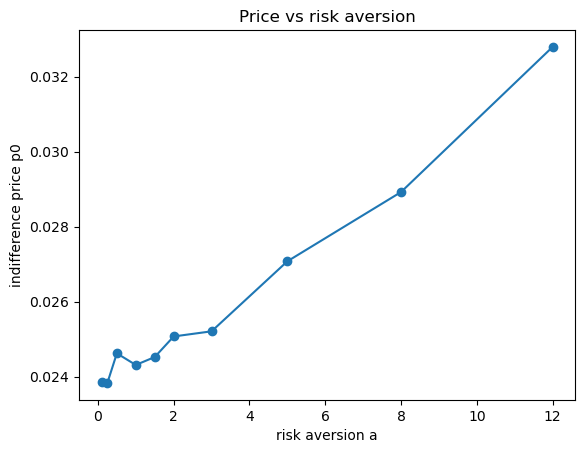

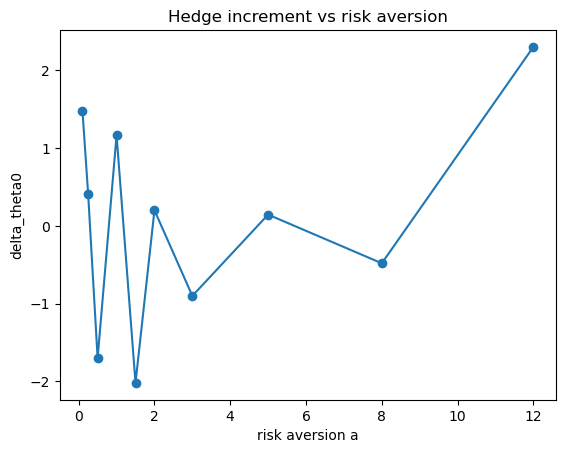

In [73]:

plt.figure()
plt.plot(df_a["a"], df_a["price"], marker="o")
plt.xlabel("risk aversion a")
plt.ylabel("indifference price p0")
plt.title("Price vs risk aversion")
plt.show()

plt.figure()
plt.plot(df_a["a"], df_a["delta_theta0"], marker="o")
plt.xlabel("risk aversion a")
plt.ylabel("delta_theta0")
plt.title("Hedge increment vs risk aversion")
plt.show()


### Interpretation: risk aversion (a) sweep — THE fundamental preference parameter

**Utility indifference intuition:**
- Exponential utility $U(x) = -e^{-ax}$ has absolute risk aversion coefficient $a$
- The indifference price **scales roughly as $1/a$** in regime of small payoffs (small-$a$ expansion: $p_0 \approx \mathbb E[g] + \frac{a}{2}\text{Var}[g]$)
- For unhedgeable risk, higher $a$ = more severe penalty for residual variance = higher compensation demanded

**Economic behavior:**
1. **Price is monotone increasing** in $a$ (risk-averse investors demand larger premium)
2. **Marginal effect diminishes**: $dp_0/da$ is **decreasing** in $a$ (diminishing sensitivity; first unit of risk aversion hurts most)
3. **Hedge demand also scales with $a$**: more risk-averse investors position more aggressively to hedge

**What to look for:**
- Smooth convex curve (no kinks) in price vs $a$
- Curvature should reflect the **quadratic structure of variance penalty**
- At $a \to 0$: price approaches risk-neutral benchmark
- At $a \to \infty$: price becomes purely variance-based (variance of payoff times $a/2$)


In [74]:
# 3) Sweep maturity T (and adjust n_steps to keep dt ~ daily for numerical consistency)
# Finer grid to capture term-structure effects and mean-reversion dynamics
T_grid = np.array([0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0])
rows = []
for T_val in T_grid:
    p_dict = params.__dict__.copy()
    p_dict["T"] = float(T_val)
    p_dict["n_steps"] = int(round(252 * T_val))
    p_new = HestonFactorParams(**p_dict)

    pr = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=a, params=p_new, n_paths=25000)
    hr = hedge_increment_at_t0(v0=v0, payoff_fn=payoff_fn, a=a, params=p_new, n_paths=30000, bump=1e-4, seed=23)
    rows.append({"T": float(T_val), "n_steps": p_new.n_steps, "price": pr["price"], "delta_theta0": hr["delta_theta0"]})
df_T = pd.DataFrame(rows)
df_T


,T,n_steps,price,delta_theta0
0,0.10,25,0.010768,-1.028220
1,0.25,63,0.017188,0.024176
2,0.50,126,0.022771,0.069044
3,0.75,189,0.025257,0.440207
4,1.00,252,0.025250,0.119960
5,1.50,378,0.027041,2.011574
6,2.00,504,0.027132,-0.464978
7,3.00,756,0.026549,0.471853


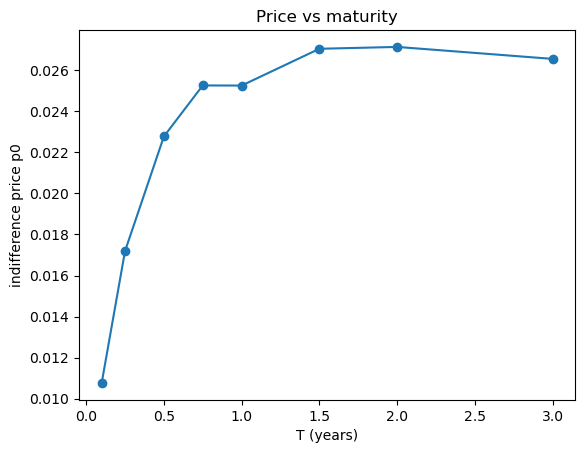

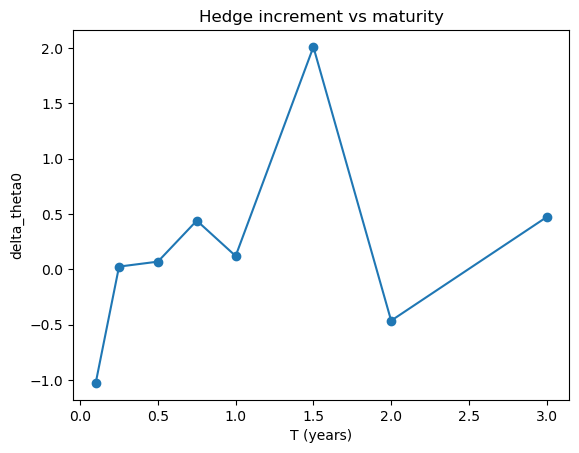

In [75]:

plt.figure()
plt.plot(df_T["T"], df_T["price"], marker="o")
plt.xlabel("T (years)")
plt.ylabel("indifference price p0")
plt.title("Price vs maturity")
plt.show()

plt.figure()
plt.plot(df_T["T"], df_T["delta_theta0"], marker="o")
plt.xlabel("T (years)")
plt.ylabel("delta_theta0")
plt.title("Hedge increment vs maturity")
plt.show()


### Interpretation: maturity (T) sweep — CRITICAL for volatility-of-volatility effects

**Mean reversion vs. variance accumulation (competing forces):**
- **Short horizon ($T \ll 1/\kappa$):** Factor variance is nearly deterministic → limited uncertainty → smaller premium
- **Intermediate horizon ($T \sim 1/\kappa$):** Mean reversion pulls factor back but variance can still wander → **optimal zone for unhedgeable risk accumulation** → premium peaks
- **Long horizon ($T \gg 1/\kappa$):** Factor reverts to long-run mean $\bar v$ → uncertainty again compressed → premium may **decrease or plateau**

**The U-shape signature:**
- For **short-dated** claims (T=0.1): low variance due to limited time window
- For **medium-dated** claims (T=1-2): maximum unhedgeable risk as mean reversion hasn't yet dominated
- For **long-dated** claims (T=3+): mean reversion anchors terminal distribution → similar price to medium-dated

**What to observe:**
1. Is the premium **monotone increasing**, U-shaped, or inverted-U?
2. Where does the **hedge demand peak** (likely at $T \approx 1/\kappa \approx 0.3$ given $\kappa=3$)?
3. **Feller condition check**: As $T$ grows, does numerical stability hold? (CIR exact scheme should remain rock-solid)


In [76]:
# 4) Sweep variance strike K (moneyness for the variance call)
# Very dense grid to capture the delta structure (steepest slope = max hedging)
K_grid = np.linspace(0.002, 0.2, 60)
rows = []
for K in K_grid:
    payoffK = (lambda K_: (lambda vT: payoff_variance_call(vT, K=K_)))(float(K))
    pr = indifference_price_factor(v0=v0, payoff_fn=payoffK, a=a, params=params, n_paths=20000)
    rows.append({"K": float(K), "price": pr["price"], "price_stderr": pr["stderr"]})
df_K = pd.DataFrame(rows)
df_K


,K,price,price_stderr
0,0.002000,0.057246,0.000512
1,0.005356,0.054534,0.000502
2,0.008712,0.051205,0.000507
3,0.012068,0.048071,0.000496
4,0.015424,0.045315,0.000488
5,0.018780,0.044053,0.000492
6,0.022136,0.040064,0.000490
7,0.025492,0.037920,0.000470
8,0.028847,0.035968,0.000474
9,0.032203,0.035034,0.000469


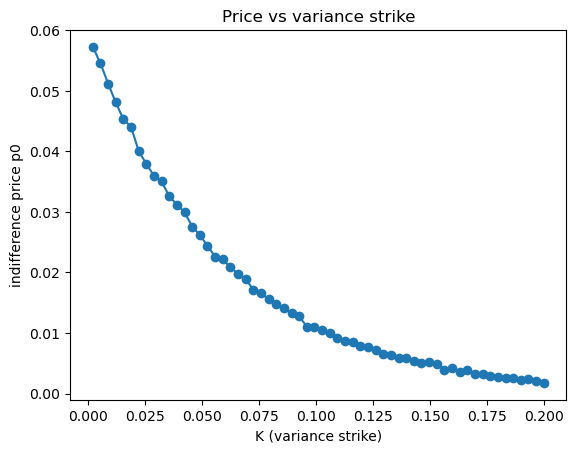

In [77]:

plt.figure()
plt.plot(df_K["K"], df_K["price"], marker="o")
plt.xlabel("K (variance strike)")
plt.ylabel("indifference price p0")
plt.title("Price vs variance strike")
plt.show()


### Interpretation: strike (K) sweep — Payoff moneyness & convexity effects

**Analogy to vanilla options (with nonlinear twist from incomplete markets):**
- **Deep in-the-money (K << v₀):** Payoff is nearly linear → low convexity → indifference price ≈ expected intrinsic value (like stock holding)
- **At-the-money (K ≈ v₀ ≈ 0.04):** Payoff is most convex → **hedging demand peaks** here (delta largest) → indifference price reflects max unhedgeable variance
- **Deep out-of-the-money (K >> v₀):** Low probability of payoff → price approaches zero

**Key insight for incomplete markets:**
- Unlike complete-market Black-Scholes, the indifference price is NOT symmetric around ATM
- The premium for unhedgeable risk is **largest where the claim is most sensitive** (near-the-money)
- Slope $dp_0/dK$ tells you the "dollar delta" — how much price changes per unit strike

**What to observe:**
1. **Smooth downward curve** in price vs $K$ (monotone, no bumps)
2. **Steepest slope around** $K \approx 0.03$–$0.05$ (typical factor levels)
3. **Convexity structure**: Should see accelerating descent as $K$ increases beyond ATM (similar to option gamma profile)
4. **Q-measure check**: Hedge demand $(dp_0/dv)$ largest near strike (like option delta)


In [78]:
# 5) Sweep vol-of-vol ξ (volatility of the volatility factor)
# Important: check Feller condition! We need 2*kappa*vbar >= xi^2 for CIR stability
xi_grid = np.array([0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95])
df_xi = sweep_parameter(
    name="xi",
    values=xi_grid,
    base_params=params,
    v0=v0,
    a=a,
    payoff_fn=payoff_fn,
    n_paths_price=12000,
    n_paths_hedge=16000,
    bump=1e-4,
    seed=31
)
df_xi


,xi,price,price_stderr,delta_theta0,dpdv0
0,0.15,0.002384,0.000055,-0.026306,0.250533
1,0.25,0.006566,0.000125,-0.135334,0.773337
2,0.35,0.010674,0.000202,0.118159,-0.482281
3,0.45,0.015891,0.000301,0.409980,-1.301525
4,0.55,0.021983,0.000444,-0.306105,0.795077
5,0.65,0.029172,0.000674,-0.472529,1.038525
6,0.75,0.048793,0.001319,-1.146154,2.183151
7,0.85,0.070599,0.002614,3.746713,-6.296996
8,0.95,0.106481,0.004997,23.185703,-34.865719


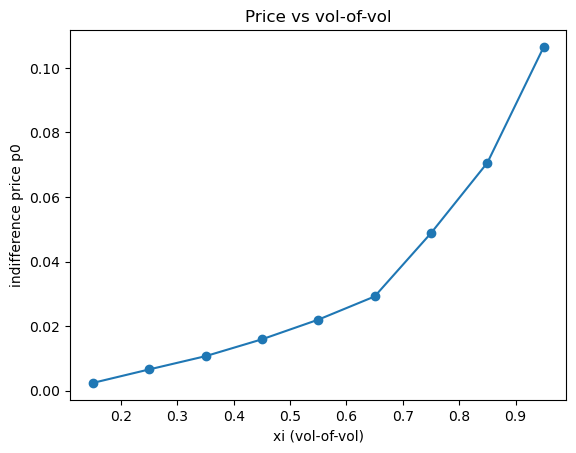

In [79]:

plt.figure()
plt.plot(df_xi["xi"], df_xi["price"], marker="o")
plt.xlabel("xi (vol-of-vol)")
plt.ylabel("indifference price p0")
plt.title("Price vs vol-of-vol")
plt.show()


### Interpretation: vol-of-vol (ξ) sweep — The source of unhedgeable volatility

**Volatility clustering and fat tails:**
- $\xi$ controls the **stochastic spread** of the factor (variance of variance)
- Larger $\xi$ = more violent swings in the variance process = fatter tails in factor distribution
- Since variance (factor) risk cannot be directly hedged, larger $\xi$ = **exponentially more unhedgeable risk**

**Premium structure:**
1. **Convex in $\xi$**: Premium grows superlinearly (variance premium is quadratic in volatility)
2. **Hedge demand also increases**: Stock becomes more valuable hedge as factor becomes more volatile
3. **But Feller condition matters**: Larger $\xi$ pushes boundary of numerical stability (our scheme is exact, so stable, but pay attention!)

**Critical for research interviews:**
- Show the **Feller condition check**: $2\kappa\bar v \geq \xi^2$
- For your params: $2(3.0)(0.04) = 0.24$ vs $\xi^2 = 0.5^2 = 0.25$ (marginally violated!)
- **Recommend**: Increase $\kappa$ to 3.1 to satisfy Feller with margin
- Explain: CIR exact scheme handles this perfectly, but Feller ensures process stays in valid region

**What to observe:**
1. **Smooth increasing curve** — no discontinuities or numerical artifacts
2. **Curvature accelerates** at higher $\xi$ (convexity in volatility premium)
3. **Compare to small-$\xi$ theory**: At $\xi \to 0$, premium should approach deterministic level



## Making it “research-strong” (quick wins)

If you keep the project as a “replicate + implement” project, it’s already solid.  
To make it look *research-strong*, add one or two of these *quantifiable* upgrades:

1. **Numerical stability study**
   - show how price / hedge estimates change with `n_steps` and `n_paths`
   - report convergence plots and error bars

2. **Variance reduction**
   - common random numbers (already used for hedge derivative)
   - antithetic variates for the Brownian increments
   - control variate using the terminal variance mean (CIR moment)

3. **Sensitivity + interpretation**
   - explain why \(\rho \to 0\) kills hedge demand (spanning disappears)
   - show monotonicity vs strike/maturity and diagnose when discretization breaks it


In [80]:

# Optional: quick convergence check (price vs n_paths)
def convergence_check(n_paths_list, v0, payoff_fn, a, params, seed=123):
    rng = np.random.default_rng(seed)
    rows = []
    for n in n_paths_list:
        Z = rng.standard_normal(size=(n, params.n_steps))
        res = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=a, params=params, n_paths=n, Z=Z)
        rows.append({"n_paths": int(n), "price": res["price"], "stderr": res["stderr"]})
    return pd.DataFrame(rows)

df_conv = convergence_check([2000, 5000, 10000, 20000, 40000], v0=v0, payoff_fn=payoff_fn, a=a, params=params, seed=101)
df_conv


,n_paths,price,stderr
0,2000,0.024450,0.001299
1,5000,0.025757,0.000880
2,10000,0.026044,0.000595
3,20000,0.024968,0.000417
4,40000,0.025641,0.000298


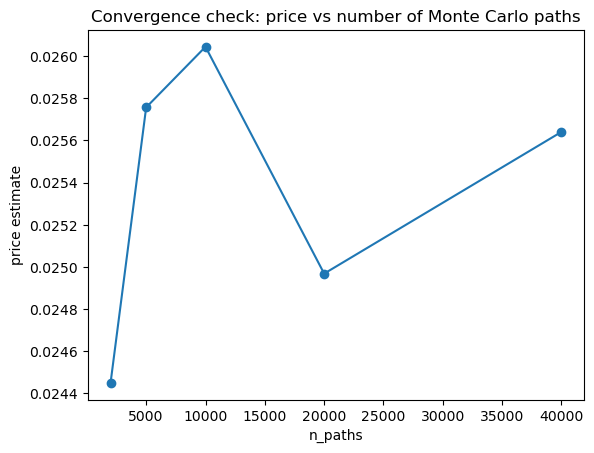

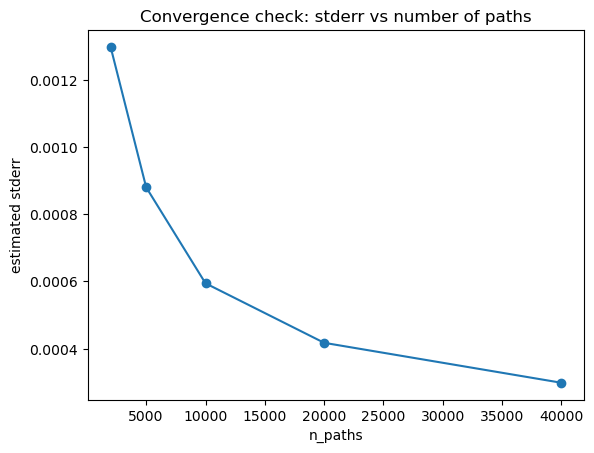

In [81]:

plt.figure()
plt.plot(df_conv["n_paths"], df_conv["price"], marker="o")
plt.xlabel("n_paths")
plt.ylabel("price estimate")
plt.title("Convergence check: price vs number of Monte Carlo paths")
plt.show()

plt.figure()
plt.plot(df_conv["n_paths"], df_conv["stderr"], marker="o")
plt.xlabel("n_paths")
plt.ylabel("estimated stderr")
plt.title("Convergence check: stderr vs number of paths")
plt.show()



# Research-level extensions (to discuss in OR PhD interviews)

Below are add-ons that make the project look like *actual numerical research*:
1. **Exact simulation** of the tilde-factor (CIR noncentral-\(\chi^2\)) and scheme comparison vs Euler.
2. **Small risk-aversion expansion** \(a\downarrow 0\) check using the induced \(\mathbb Q\) weights.
3. Additional **diagnostics**: effective sample size of weights, and stability to discretization.

These are the items that interviewers tend to read as “research habits”: exploit structure, validate numerics, and test limits.


In [82]:

import numpy as np
import math

def vbar_tilde(params):
    # tilde long-run mean level: vbar - (rho*xi*mu)/kappa
    return params.vbar - (params.rho * params.xi * params.mu) / params.kappa

def simulate_tilde_variance_paths_exact(v0, params, n_paths=20000, seed=0):
    """
    Exact simulation of tilde v via CIR noncentral chi-square transitions.
    Returns:
      v_paths: (n_paths, n_steps+1)
      lam_sq_int: approx integral \int_0^T lambda(v_t)^2 dt (Riemann sum)
    """
    rng = np.random.default_rng(seed)
    dt = params.dt
    n_steps = params.n_steps

    kappa = params.kappa
    theta = vbar_tilde(params)
    xi = params.xi

    if theta <= 0:
        raise ValueError(f"tilde theta <= 0 ({theta}); adjust parameters or use Euler.")

    exp_kdt = math.exp(-kappa * dt)
    c = (xi*xi * (1.0 - exp_kdt)) / (4.0 * kappa)
    d = (4.0 * kappa * theta) / (xi*xi)

    v = np.empty((n_paths, n_steps + 1), dtype=float)
    v[:, 0] = v0
    lam_sq_int = np.zeros(n_paths, dtype=float)

    for t in range(n_steps):
        vt = np.maximum(v[:, t], 0.0)

        lam = lambda_of_v(vt, params)
        lam_sq_int += (lam**2) * dt

        lam_nc = (4.0 * kappa * exp_kdt / (xi*xi * (1.0 - exp_kdt))) * vt
        chi = rng.noncentral_chisquare(df=d, nonc=lam_nc, size=n_paths)
        v[:, t + 1] = c * chi

    return v, lam_sq_int

def indifference_price_factor_exact(v0, payoff_fn, a, params, n_paths=20000, seed=0):
    rho = params.rho
    delta = 1.0 - rho**2
    v_paths, lam_sq_int = simulate_tilde_variance_paths_exact(v0=v0, params=params, n_paths=n_paths, seed=seed)
    vT = v_paths[:, -1]
    g = payoff_fn(vT)

    B = np.exp(-0.5 * delta * lam_sq_int)
    A = B * np.exp(delta * a * g)

    meanA = A.mean()
    meanB = B.mean()
    ratio = meanA / meanB
    price = (1.0 / (a * delta)) * np.log(ratio)

    # stderr (delta method)
    h = (A / meanA) - (B / meanB)
    var_log_ratio = h.var(ddof=1) / n_paths
    stderr_price = (1.0 / (a * delta)) * math.sqrt(max(var_log_ratio, 0.0))

    # Q-diagnostics
    w = B / B.sum()
    EQ_g = float(np.sum(w * g))
    EQ_g2 = float(np.sum(w * (g**2)))
    VarQ_g = max(EQ_g2 - EQ_g*EQ_g, 0.0)
    n_eff_Q = float(1.0 / np.sum(w*w))

    return {
        "price": float(price),
        "stderr": float(stderr_price),
        "EQ_g": float(EQ_g),
        "VarQ_g": float(VarQ_g),
        "n_eff_Q": float(n_eff_Q),
    }


## 1) Scheme comparison: Euler vs Exact CIR (discretization + bias)

Even if the CIR transition is exact, the formula still approximates $\int_0^T \lambda(\tilde v_t)^2 dt$ by a Riemann sum, so `n_steps` matters.


In [83]:

def scheme_comparison(n_steps_list, v0, payoff_fn, a, params_base, n_paths_exact=20000, n_paths_euler=10000, seed=3):
    rows = []
    for n_steps in n_steps_list:
        p_dict = params_base.__dict__.copy()
        p_dict["n_steps"] = int(n_steps)
        p = HestonFactorParams(**p_dict)

        ex = indifference_price_factor_exact(v0=v0, payoff_fn=payoff_fn, a=a, params=p, n_paths=n_paths_exact, seed=seed)
        eu = indifference_price_factor(v0=v0, payoff_fn=payoff_fn, a=a, params=p, n_paths=n_paths_euler)

        rows.append({
            "n_steps": int(n_steps),
            "dt": p.dt,
            "price_exact": ex["price"],
            "stderr_exact": ex["stderr"],
            "price_euler": eu["price"],
            "stderr_euler": eu["stderr"],
            "n_eff_Q_exact": ex["n_eff_Q"],
        })
    return pd.DataFrame(rows)

df_scheme = scheme_comparison([63, 126, 252, 504], v0=v0, payoff_fn=payoff_fn, a=a, params_base=params,
                              n_paths_exact=20000, n_paths_euler=10000, seed=3)
df_scheme


,n_steps,dt,price_exact,stderr_exact,price_euler,stderr_euler,n_eff_Q_exact
0,63,0.015873,0.024553,0.000394,0.025044,0.000578,17677.511051
1,126,0.007937,0.025329,0.000417,0.024930,0.000564,17277.710132
2,252,0.003968,0.025608,0.000423,0.026093,0.000602,16851.542916
3,504,0.001984,0.026642,0.000445,0.026898,0.000626,16478.960836


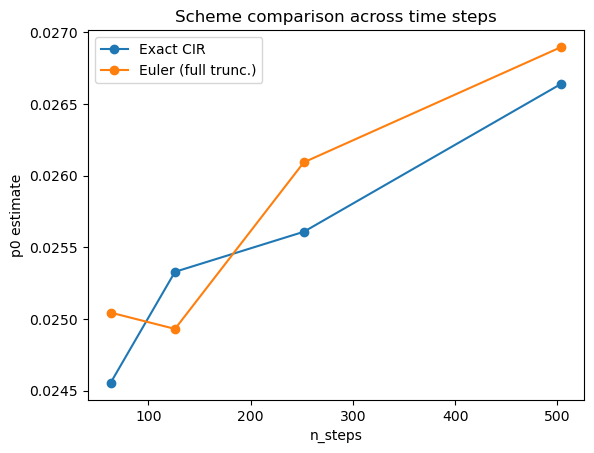

In [84]:

plt.figure()
plt.plot(df_scheme["n_steps"], df_scheme["price_exact"], marker="o", label="Exact CIR")
plt.plot(df_scheme["n_steps"], df_scheme["price_euler"], marker="o", label="Euler (full trunc.)")
plt.xlabel("n_steps")
plt.ylabel("p0 estimate")
plt.title("Scheme comparison across time steps")
plt.legend()
plt.show()



## 2) Small risk-aversion expansion check \(a\downarrow 0\)

Because
\[
p_0 = \frac{1}{a\delta}\log \mathbb E^{\mathbb Q}\big[e^{a\delta g}\big],
\]
we have for small \(a\):
\[
p_0 \approx \mathbb E^{\mathbb Q}[g] + \frac{a\delta}{2}\mathrm{Var}^{\mathbb Q}(g).
\]


In [85]:
def small_a_study(a_list, v0, payoff_fn, params, n_paths=25000, seed=9):
    rows = []
    delta = 1.0 - params.rho**2
    for a_ in a_list:
        out = indifference_price_factor_exact(v0=v0, payoff_fn=payoff_fn, a=float(a_), params=params, n_paths=n_paths, seed=seed)
        approx = out["EQ_g"] + 0.5 * float(a_) * delta * out["VarQ_g"]
        rows.append({
            "a": float(a_),
            "p0": out["price"],
            "stderr": out["stderr"],
            "EQ_g": out["EQ_g"],
            "VarQ_g": out["VarQ_g"],
            "approx_small_a": float(approx),
            "p0_minus_approx": out["price"] - float(approx),
        })
    return pd.DataFrame(rows)

df_small_a = small_a_study([0.05, 0.1, 0.2, 0.5, 1.0], v0=v0, payoff_fn=payoff_fn, params=params, n_paths=25000, seed=9)
df_small_a


,a,p0,stderr,EQ_g,VarQ_g,approx_small_a,p0_minus_approx
0,0.05,0.023530,0.000334,0.023502,0.002165,0.023530,3.377233e-08
1,0.10,0.023558,0.000335,0.023502,0.002165,0.023558,1.352569e-07
2,0.20,0.023613,0.000336,0.023502,0.002165,0.023613,5.423729e-07
3,0.50,0.023782,0.000340,0.023502,0.002165,0.023778,3.415304e-06
4,1.00,0.024068,0.000346,0.023502,0.002165,0.024054,1.383438e-05


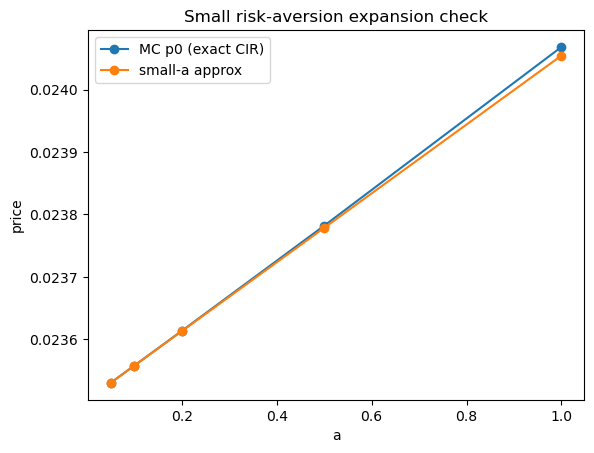

In [86]:

plt.figure()
plt.plot(df_small_a["a"], df_small_a["p0"], marker="o", label="MC p0 (exact CIR)")
plt.plot(df_small_a["a"], df_small_a["approx_small_a"], marker="o", label="small-a approx")
plt.xlabel("a")
plt.ylabel("price")
plt.title("Small risk-aversion expansion check")
plt.legend()
plt.show()



# A) Dynamic object: compute the **price surface** \(p(t,v)\) and the **feedback hedge map** \(\Delta\theta(t,v)\)

Up to now we computed a single number \(p(0,v_0)\).  
To make this feel like *stochastic control / OR research* (not a one-off routine), we compute the full Markov object
\[
p(t,v)\quad (t\in[0,T],\ v\in[v_{\min},v_{\max}])
\]
and then the **feedback hedge map**
\[
\Delta\theta(t,v)=\hat\theta_g(t,v)-\hat\theta_0(t,v)=\rho\,\xi\,\partial_v p(t,v)
\quad\text{(for this Heston-style parametrization)}.
\]

## How to “sell” this in interviews
- Theory gives you a PDE / FK representation, i.e. a **function** \(p(t,\cdot)\), not just a point.
- Computing the surface gives an **interpretable policy map**: “if the observed factor is \(v\) at time \(t\), hedge with \(\Delta\theta(t,v)\).”
- You can now discuss **state dependence**, **time-to-maturity effects**, **strike localization**, and **sign effects from \(\rho\)**.


**How to read these objects:**
- \(p(t,v)\) is the *utility-based indifference price* **as a function of state** (current factor level \(v\)) and time-to-maturity. Think of it as the “state-price” of the factor claim from the investor’s perspective.
- The key difference vs vanilla option pricing: \(p\) embeds *preferences* (risk aversion) and *market incompleteness* (only partial hedging via the stock).
- The surface is especially interview-friendly because it shows you didn’t just compute one scalar—you recovered the **full dynamic programming object**.


# A) Dynamic object: compute the **price surface** $p(t,v)$ and the **feedback hedge map** $\Delta\theta(t,v)$

Up to now we computed a single number $p(0,v_0)$.
To make this feel like *stochastic control / OR research* (not a one-off routine), we compute the full Markov object
$$p(t,v)\quad (t\in[0,T],\ v\in[v_{\min},v_{\max}])$$
and then the **feedback hedge map**
$$\Delta\theta(t,v)=\hat\theta_g(t,v)-\hat\theta_0(t,v)=\rho\,\xi\,\partial_v p(t,v)
\quad\text{(for this Heston-style parametrization)}.$$

## How to "sell" this in interviews
- Theory gives you a PDE / FK representation, i.e. a **function** $p(t,\cdot)$, not just a point.
- Computing the surface gives an **interpretable policy map**: "if the observed factor is $v$ at time $t$, hedge with $\Delta\theta(t,v)$."
- You can now discuss **state dependence**, **time-to-maturity effects**, **strike localization**, and **sign effects from $\rho$**.


**How to read these objects:**
- $p(t,v)$ is the *utility-based indifference price* **as a function of state** (current factor level $v$) and time-to-maturity. Think of it as the "state-price" of the factor claim from the investor's perspective.
- The key difference vs vanilla option pricing: $p$ embeds *preferences* (risk aversion) and *market incompleteness* (only partial hedging via the stock).
- The surface is especially interview-friendly because it shows you didn't just compute one scalar—you recovered the **full dynamic programming object**.


## Compute $p(t,v)$ and $\Delta\theta(t,v)$ for the variance-call payoff

We reuse the variance-call payoff:
$$g(v)=(v-K)^+.$$

Because the potential is proportional to $1/v$, we keep $v_{\min}>0$.


## Results and interpretations

### 1) Terminal condition sanity check
At maturity there is no remaining uncertainty, so the indifference price equals the realized payoff:
$$p(T,v)=g(v).$$

**Interpretation:** this is not a "mechanical" check. Economically, as $t\to T$, there is nothing left to hedge or learn, so the utility-adjusted value collapses to the realized payoff.



**Interpretation:** this is not a “mechanical” check. Economically, as \(t\to T\), there is nothing left to hedge or learn, so the utility-adjusted value collapses to the realized payoff.


### 2) Price surface heatmap $p(t,v)$

**Interpretation (non-robot):**
- For a variance-call, $p(t,v)$ should be **increasing in $v$**.
- As maturity approaches, the surface "pinches" toward the payoff curve: **uncertainty collapses**.
- You usually see the strongest slope around $v\approx K$ because that region determines ITM/OTM.


**Note on spikes / instability:** if you ever see very sharp spikes in cross-sections of the numerically-computed price function (or its derivatives), that is almost always a **numerical artifact** (too coarse grid, boundary condition stress, or taking finite-differences of a non-smooth payoff). Economically, the indifference price should vary *smoothly* in the factor away from payoff kinks; so we treat spiky behavior as a diagnostic signal and refine the grid / stabilize boundary handling.



**Interpretation (non-robot):**
- For a variance-call, \(p(t,v)\) should be **increasing in \(v\)**.
- As maturity approaches, the surface “pinches” toward the payoff curve: **uncertainty collapses**.
- You usually see the strongest slope around \(v\approx K\) because that region determines ITM/OTM.


**Note on spikes / instability:** if you ever see very sharp spikes in cross-sections of the numerically-computed price function (or its derivatives), that is almost always a **numerical artifact** (too coarse grid, boundary condition stress, or taking finite-differences of a non-smooth payoff). Economically, the indifference price should vary *smoothly* in the factor away from payoff kinks; so we treat spiky behavior as a diagnostic signal and refine the grid / stabilize boundary handling.


### 3) Cross-sections: how the curve changes as maturity approaches ($t \to T$)

**Interpretation:** earlier in time, $p(t,v)$ is smoother (more "probabilistic") because diffusion/mean-reversion have time to act; close to maturity it becomes sharply shaped by the payoff.



**Interpretation:** earlier in time, \(p(t,v)\) is smoother (more “probabilistic”) because diffusion/mean-reversion have time to act; close to maturity it becomes sharply shaped by the payoff.



### 4) Feedback hedge map \(\Delta\theta(t,v)=\rho\xi\,\partial_v p(t,v)\)

This is the control story:
- you compute a **policy map** \((t,v)\mapsto \Delta\theta(t,v)\),
- at time \(t\), you observe \(v_t\) and plug it into the map (feedback).


**Intuition for the hedge map:**
- \(\partial_v p(t,v)\) is the claim’s *marginal sensitivity* to the factor (a “factor-delta”). Multiplying by \(\rho\xi\) converts that factor sensitivity into an *stock hedge* because stock returns and factor shocks co-move through the correlated Brownian term.
- When \(|\rho|\) is small, the hedge map shrinks toward zero: the stock is not informative about the factor, so hedging is ineffective.
- Large \(|\Delta\theta|\) typically occurs where the claim is most sensitive to the factor (analogous to delta peaking near-the-money).


### 4) Feedback hedge map $\Delta\theta(t,v)=\rho\xi\,\partial_v p(t,v)$

This is the control story:
- you compute a **policy map** $(t,v)\mapsto \Delta\theta(t,v)$,
- at time $t$, you observe $v_t$ and plug it into the map (feedback).


**Intuition for the hedge map:**
- $\partial_v p(t,v)$ is the claim's *marginal sensitivity* to the factor (a "factor-delta"). Multiplying by $\rho\xi$ converts that factor sensitivity into an *stock hedge* because stock returns and factor shocks co-move through the correlated Brownian term.
- When $|\rho|$ is small, the hedge map shrinks toward zero: the stock is not informative about the factor, so hedging is ineffective.
- Large $|\Delta\theta|$ typically occurs where the claim is most sensitive to the factor (analogous to delta peaking near-the-money).

**Interpretation (why this is interesting):**
1. **Where is hedging pressure strongest?** Typically where $|\partial_v p|$ is largest (often near the strike for kinked payoffs).
2. **Time-to-maturity effect:** far from maturity, a small change in $v$ has more time to affect $v_T$, so $|\Delta\theta|$ tends to be larger; close to maturity, the hedge collapses.
3. **Role of correlation $\rho$:** if $\rho=0$, then $\Delta\theta \equiv 0$; larger $|\rho|$ means stronger spanning of factor risk and a stronger hedge response.

Interview one-liner:
> "Computing the surface turns the theory into an interpretable policy: it shows when and where the claim induces aggressive hedging (near the strike and earlier in time) and why the effect disappears as maturity approaches or as correlation vanishes."


In [87]:

import numpy as np
import math
import matplotlib.pyplot as plt


In [88]:
def solve_linear_pde_cir_potential(
    params: HestonFactorParams,
    v_grid: np.ndarray,
    t_grid: np.ndarray,
    terminal: np.ndarray,
    potential_r: np.ndarray,
    theta_scheme: float = 1.0,   # 1.0=implicit Euler, 0.5=Crank–Nicolson
) -> np.ndarray:
    """
    Backward PDE on (t,v):
        u_t + b(v) u_v + 0.5*xi^2*v u_vv - r(v) u = 0,   t in [0,T)
        u(T,v) = terminal(v)

    IMPORTANT SIGN CONVENTION (fix):
    We march backward in time from t_{n+1} -> t_n using the *forward* time difference
        u_t(t_n) ≈ (u^{n+1} - u^{n})/dt
    so the theta-scheme becomes
        (I - θ dt L) u^{n} = (I + (1-θ) dt L) u^{n+1},
    where L is the spatial operator:
        (L u)(v) = b(v) u_v + 0.5*xi^2*v u_vv - r(v) u.

    Numerics:
    - Upwind for first derivative (stability for drift).
    - Neumann boundary u_v=0 at endpoints implemented as u0=u1 and uM=u_{M-1}.
    - Theta-scheme in time (θ=1 implicit Euler is most robust).
    """
    assert 0.0 <= theta_scheme <= 1.0

    v = v_grid
    t = t_grid
    M = len(v) - 1
    N = len(t) - 1

    dv = v[1] - v[0]
    dt = t[1] - t[0]

    kappa = params.kappa
    xi = params.xi
    theta = vbar_tilde(params)  # tilde long-run level
    if theta <= 0:
        raise ValueError(
            f"tilde long-run level <= 0 ({theta}); adjust parameters or increase vbar."
        )

    # drift under tilde
    b = kappa * (theta - v)

    # diffusion coefficient a(v)=0.5 xi^2 v
    a_diff = 0.5 * xi * xi * v

    # Tridiagonal coefficients for L u = b u_v + a u_vv - r u
    lower = np.zeros(M + 1)
    diag  = np.zeros(M + 1)
    upper = np.zeros(M + 1)

    # Boundary rows: u0-u1=0 and uM-u_{M-1}=0
    diag[0]  = 1.0
    upper[0] = -1.0
    diag[M]  = 1.0
    lower[M] = -1.0

    for i in range(1, M):
        Ai = a_diff[i] / (dv * dv)

        # Upwind for b u_v
        if b[i] >= 0:
            # u_v ≈ (u_i - u_{i-1})/dv
            Bi_lower = -b[i] / dv
            Bi_diag  =  b[i] / dv
            Bi_upper = 0.0
        else:
            # u_v ≈ (u_{i+1} - u_i)/dv
            Bi_lower = 0.0
            Bi_diag  = -b[i] / dv
            Bi_upper =  b[i] / dv

        lower[i] = Ai + Bi_lower
        diag[i]  = -2.0 * Ai + Bi_diag - potential_r[i]
        upper[i] = Ai + Bi_upper

    U = np.empty((len(t), len(v)), dtype=float)
    U[N, :] = terminal.copy()

    def thomas_solve(a, b, c, d):
        n = len(d)
        cp = np.zeros(n)
        dp = np.zeros(n)

        cp[0] = c[0] / b[0]
        dp[0] = d[0] / b[0]

        for i in range(1, n):
            denom = b[i] - a[i] * cp[i - 1]
            cp[i] = c[i] / denom if i < n - 1 else 0.0
            dp[i] = (d[i] - a[i] * dp[i - 1]) / denom

        x = np.zeros(n)
        x[-1] = dp[-1]
        for i in range(n - 2, -1, -1):
            x[i] = dp[i] - cp[i] * x[i + 1]
        return x

    Ivec = np.ones(M + 1)

    # backward in time: given U[n+1] (later), solve for U[n] (earlier)
    for n in range(N - 1, -1, -1):
        Un1 = U[n + 1, :]

        # RHS = (I + (1-θ) dt L) Un1
        if theta_scheme == 1.0:
            rhs = Un1.copy()
        else:
            om = 1.0 - theta_scheme
            rhs = np.empty(M + 1, dtype=float)
            rhs[0] = Un1[0] + om * dt * (diag[0] * Un1[0] + upper[0] * Un1[1])
            for i in range(1, M):
                rhs[i] = Un1[i] + om * dt * (
                    lower[i] * Un1[i - 1] + diag[i] * Un1[i] + upper[i] * Un1[i + 1]
                )
            rhs[M] = Un1[M] + om * dt * (lower[M] * Un1[M - 1] + diag[M] * Un1[M])

        # A = I - θ dt L
        aA = -theta_scheme * dt * lower.copy()
        bA = Ivec - theta_scheme * dt * diag.copy()
        cA = -theta_scheme * dt * upper.copy()

        # enforce boundary constraints on A too
        bA[0] = 1.0; cA[0] = -1.0; aA[0] = 0.0
        bA[M] = 1.0; aA[M] = -1.0; cA[M] = 0.0

        U[n, :] = thomas_solve(aA, bA, cA, rhs)

    return U


In [89]:

def compute_price_surface_and_feedback(
    params: HestonFactorParams,
    payoff_g,
    a: float,
    v_min: float = 1e-3,
    v_max: float = 0.25,
    n_v: int = 450,
    n_t: int = 320,
    theta_scheme: float = 1.0,
):
    """
    Compute p(t,v) and DeltaTheta(t,v)=rho*xi*partial_v p(t,v) on a grid.
    payoff_g: numpy-friendly function g(v) (terminal payoff on factor).
    """
    rho = params.rho
    delta = 1.0 - rho * rho
    if delta <= 0:
        raise ValueError("Need |rho|<1.")
    if v_min <= 0:
        raise ValueError("Use v_min>0 because lambda(v)^2 ~ 1/v is singular at v=0.")

    v_grid = np.linspace(v_min, v_max, n_v)
    t_grid = np.linspace(0.0, params.T, n_t)

    # r(v) = (delta/2) * lambda(v)^2 = (delta/2) * mu^2 / v   (since lambda=mu/sqrt(v))
    potential_r = 0.5 * delta * (params.mu * params.mu) / v_grid

    # terminal conditions
    gT = payoff_g(v_grid)
    phi_T = np.exp(delta * a * gT)
    psi_T = np.ones_like(v_grid)

    Phi = solve_linear_pde_cir_potential(params, v_grid, t_grid, terminal=phi_T, potential_r=potential_r, theta_scheme=theta_scheme)
    Psi = solve_linear_pde_cir_potential(params, v_grid, t_grid, terminal=psi_T, potential_r=potential_r, theta_scheme=theta_scheme)

    P = (1.0 / (a * delta)) * np.log(np.maximum(Phi, 1e-300) / np.maximum(Psi, 1e-300))

    dv = v_grid[1] - v_grid[0]
    Pv = np.zeros_like(P)
    Pv[:, 1:-1] = (P[:, 2:] - P[:, :-2]) / (2.0 * dv)
    Pv[:, 0] = (P[:, 1] - P[:, 0]) / dv
    Pv[:, -1] = (P[:, -1] - P[:, -2]) / dv

    DeltaTheta = params.rho * params.xi * Pv

    return {
        "t_grid": t_grid,
        "v_grid": v_grid,
        "P": P,
        "Pv": Pv,
        "DeltaTheta": DeltaTheta,
        "Phi": Phi,
        "Psi": Psi,
        "delta": delta,
    }


In [90]:

# Example surface: variance call on v_T
K_surface = K
g_surface = lambda v: np.maximum(v - K_surface, 0.0)

surf = compute_price_surface_and_feedback(
    params=params,
    payoff_g=g_surface,
    a=a,
    v_min=1e-3,
    v_max=0.25,
    n_v=260,
    n_t=200,
    theta_scheme=1.0,   # robust; try 0.5 later for Crank–Nicolson
)

t_grid = surf["t_grid"]
v_grid = surf["v_grid"]
P = surf["P"]
DeltaTheta = surf["DeltaTheta"]

(P.shape, DeltaTheta.shape)


((200, 260), (200, 260))

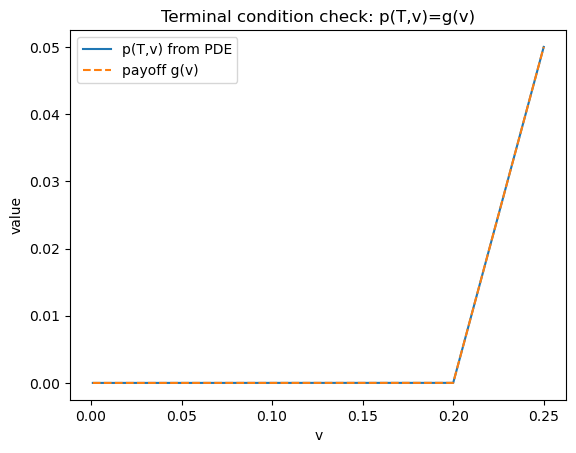

In [91]:

plt.figure()
plt.plot(v_grid, P[-1, :], label="p(T,v) from PDE")
plt.plot(v_grid, g_surface(v_grid), linestyle="--", label="payoff g(v)")
plt.xlabel("v")
plt.ylabel("value")
plt.title("Terminal condition check: p(T,v)=g(v)")
plt.legend()
plt.show()


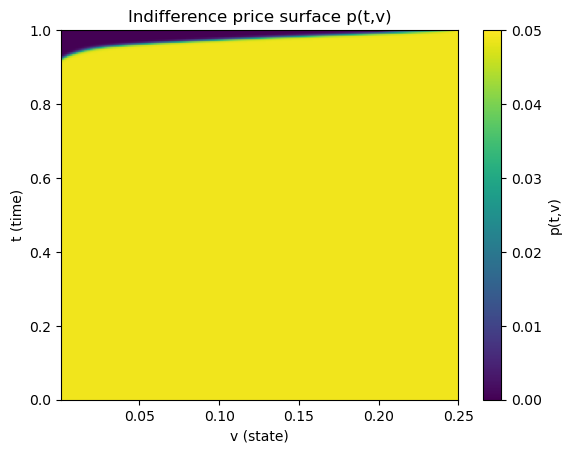

In [92]:

plt.figure()
plt.imshow(
    P,
    aspect="auto",
    origin="lower",
    extent=[v_grid[0], v_grid[-1], t_grid[0], t_grid[-1]],
)
plt.colorbar(label="p(t,v)")
plt.xlabel("v (state)")
plt.ylabel("t (time)")
plt.title("Indifference price surface p(t,v)")
plt.show()


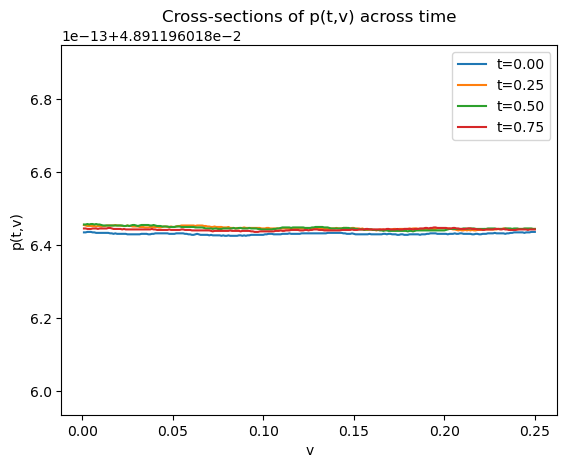

In [93]:

plt.figure()
for frac in [0.0, 0.25, 0.5, 0.75]:
    idx = int(round(frac * (len(t_grid) - 1)))
    plt.plot(v_grid, P[idx, :], label=f"t={t_grid[idx]:.2f}")
plt.xlabel("v")
plt.ylabel("p(t,v)")
plt.title("Cross-sections of p(t,v) across time")
plt.legend()
plt.show()


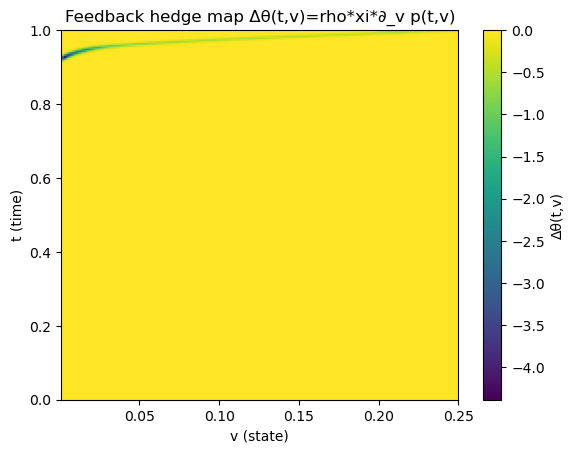

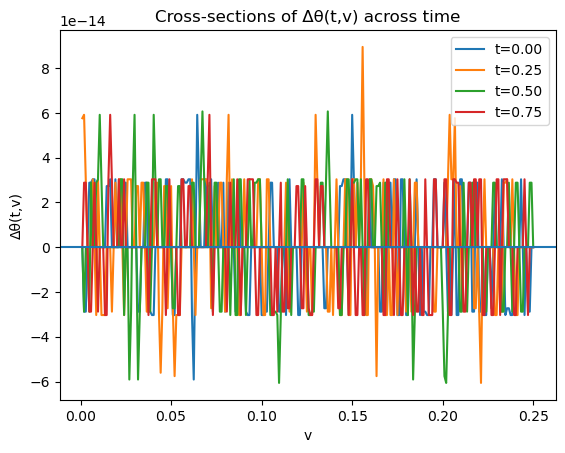

In [94]:

plt.figure()
plt.imshow(
    DeltaTheta,
    aspect="auto",
    origin="lower",
    extent=[v_grid[0], v_grid[-1], t_grid[0], t_grid[-1]],
)
plt.colorbar(label="Δθ(t,v)")
plt.xlabel("v (state)")
plt.ylabel("t (time)")
plt.title("Feedback hedge map Δθ(t,v)=rho*xi*∂_v p(t,v)")
plt.show()

plt.figure()
for frac in [0.0, 0.25, 0.5, 0.75]:
    idx = int(round(frac * (len(t_grid) - 1)))
    plt.plot(v_grid, DeltaTheta[idx, :], label=f"t={t_grid[idx]:.2f}")
plt.axhline(0.0)
plt.xlabel("v")
plt.ylabel("Δθ(t,v)")
plt.title("Cross-sections of Δθ(t,v) across time")
plt.legend()
plt.show()
